In [5]:
import pandas as pd
import os
import glob

In [2]:
data_2016_1_path = "data/Generacion_(kWh)_2016SEM1.xlsx"

In [3]:
df_2016sem1 = pd.read_excel(data_2016_1_path, skiprows=2)

In [4]:
df_2016sem1

,Fecha,Recurso,Tipo Generación,Combustible,Código Agente,Tipo Despacho,Es Menor,Es Autogenerador,0,1,...,15,16,17,18,19,20,21,22,23,Version
0,2016-01-01,AGUA FRESCA,HIDRAULICA,AGUA,ADCG,NO DESPACHADO CENTRALMENTE,SI,NO,3108.00,3079.20,...,4015.20,3967.20,3889.20,4899.60,5391.60,5337.60,5414.40,3820.80,3188.40,TX3
1,2016-01-01,ALBAN,HIDRAULICA,AGUA,EPSG,DESPACHADO CENTRALMENTE,NO,NO,3984.00,3952.00,...,3998.00,4002.00,3992.00,3994.00,3998.00,3980.00,3972.00,3974.00,3974.00,TX3
2,2016-01-01,AMOYA LA ESPERANZA,HIDRAULICA,AGUA,ISGG,DESPACHADO CENTRALMENTE,NO,NO,19380.00,19389.00,...,18817.00,18803.00,18474.00,18723.00,18661.00,18753.00,18776.00,18883.00,19047.00,TX3
3,2016-01-01,ASNAZU,HIDRAULICA,AGUA,GNCG,NO DESPACHADO CENTRALMENTE,SI,NO,209.44,149.66,...,85.20,92.35,107.53,218.68,293.65,248.22,195.91,145.04,100.76,TX3
4,2016-01-01,AYURA,HIDRAULICA,AGUA,EPMG,NO DESPACHADO CENTRALMENTE,SI,NO,5676.40,5674.87,...,5943.20,5941.67,5941.67,5943.20,5943.20,5941.67,5940.14,5941.67,5944.74,TX3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26122,2016-06-30,SAN FRANCISCO,HIDRAULICA,AGUA,EPMG,DESPACHADO CENTRALMENTE,NO,NO,NaN,NaN,...,NaN,1899.00,45266.00,85440.00,90641.00,90438.00,6069.00,NaN,NaN,TX4
26123,2016-06-30,TASAJERO 1,TERMICA,CARBON,TRMG,DESPACHADO CENTRALMENTE,NO,NO,NaN,NaN,...,163375.70,163430.20,163638.29,163312.64,163179.26,163443.59,163540.82,163430.33,163505.27,TX4
26124,2016-06-30,AUTOG YAGUARITO,TERMICA,BAGAZO,EMSG,NO DESPACHADO CENTRALMENTE,NO,SI,NaN,NaN,...,277.95,75.15,206.10,174.60,45.60,55.50,106.95,189.45,171.15,TX4
26125,2016-06-30,PROELECTRICA 1,TERMICA,GAS,PRIG,DESPACHADO CENTRALMENTE,NO,NO,NaN,NaN,...,NaN,NaN,6220.98,31663.91,42737.76,43790.28,43900.50,43881.30,42068.89,TX4


In [ ]:
ruta_global = "data/Generacion_(kWh)_*.xlsx"
archivos_excel = glob.glob(ruta_global)

In [ ]:
import pandas as pd
import os
import glob

# Ruta donde están los archivos de Excel
ruta_archivos = "data/Generacion_(kWh)_*.xlsx"  # Cambia esto por la ruta real

# Función para detectar la fila del encabezado
def detectar_fila_header(archivo):
    df_temp = pd.read_excel(archivo, header=None)  # Leer sin encabezado
    
    for i, row in df_temp.iterrows():
        if "Fecha" in row.values:  # Detectar fila que contiene "Fecha"
            return i  # Devolver el índice de la fila con los encabezados reales
    
    return 0  # Si no se encuentra "Fecha", usar la primera fila por defecto

# Buscar todos los archivos Excel en la carpeta
archivos_excel = glob.glob(ruta_archivos)  # Ajusta la extensión si es necesario

# Lista para almacenar los DataFrames filtrados
dfs_filtrados = []

# Recorrer cada archivo y filtrar la información de JEPIRACHI (coincidencia parcial)
for archivo in archivos_excel:
    try:
        # Detectar la fila del encabezado dinámicamente
        fila_header = detectar_fila_header(archivo)
        
        # Leer el archivo con el encabezado detectado
        df = pd.read_excel(archivo, skiprows=fila_header)  

        # Limpiar nombres de columnas
        df.columns = df.columns.astype(str).str.strip()

        # Verificar si la columna "Recurso" existe antes de filtrar
        if "Recurso" not in df.columns:
            raise ValueError(f"El archivo {archivo} no contiene la columna 'Recurso'. Columnas encontradas: {df.columns.tolist()}")

        # Filtrar filas donde "Recurso" contenga "JEPIRACHI"
        df_jepirachi = df[df["Recurso"].str.contains("JEPIRACHI", case=False, na=False)]
        
        if not df_jepirachi.empty:
            dfs_filtrados.append(df_jepirachi)  # Agregar a la lista si tiene datos
        
        print(f"Procesado: {archivo} - Fila de encabezado: {fila_header} - Filas encontradas: {len(df_jepirachi)}")

    except Exception as e:
        print(f"Error procesando {archivo}: {e}")

# Unir todos los DataFrames en uno solo
df_consolidado = pd.concat(dfs_filtrados, ignore_index=True)

# Guardar en un archivo Excel (opcional)
# df_consolidado.to_excel("JEPIRACHI_consolidado.xlsx", index=False)

# También podrías guardarlo como CSV si lo prefieres
# df_consolidado.to_csv("JEPIRACHI_consolidado.csv", index=False)

# Mostrar un resumen del DataFrame consolidado
print(f"Total de filas consolidadas: {df_consolidado.shape[0]}")
df_consolidado.head()  # Muestra las primeras filas del DataFrame


Procesado: data/Generacion_(kWh)_2023.xlsx - Fila de encabezado: 2 - Filas encontradas: 281
Procesado: data/Generacion_(kWh)_2016SEM2.xlsx - Fila de encabezado: 2 - Filas encontradas: 159
Procesado: data/Generacion_(kWh)_2004.xlsx - Fila de encabezado: 1 - Filas encontradas: 335
Procesado: data/Generacion_(kWh)_2007.xlsx - Fila de encabezado: 2 - Filas encontradas: 365
Procesado: data/Generacion_(kWh)_2022.xlsx - Fila de encabezado: 2 - Filas encontradas: 363
Procesado: data/Generacion_(kWh)_2012.xlsx - Fila de encabezado: 2 - Filas encontradas: 366
Procesado: data/Generacion_(kWh)_2010.xlsx - Fila de encabezado: 2 - Filas encontradas: 364
Procesado: data/Generacion_(kWh)_2005.xlsx - Fila de encabezado: 1 - Filas encontradas: 364
Procesado: data/Generacion_(kWh)_2019.xlsx - Fila de encabezado: 2 - Filas encontradas: 365
Procesado: data/Generacion_(kWh)_2020.xlsx - Fila de encabezado: 2 - Filas encontradas: 151
Procesado: data/Generacion_(kWh)_2011.xlsx - Fila de encabezado: 2 - Filas e

,Fecha,Recurso,Código Recurso,Tipo Generación,Combustible,Código Agente,Tipo Despacho,Es Menor,Clasificación,0,...,17,18,19,20,21,22,23,Version,Es Autogenerador,Tipo Generacion
0,2023-01-01 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,3368.03,...,9393.80,4689.14,2464.18,2663.03,2508.75,1790.45,1787.93,TX6,NaN,NaN
1,2023-01-02 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,866.68,...,6602.81,5630.79,4151.66,3076.85,3398.46,3014.56,3156.17,TX6,NaN,NaN
2,2023-01-03 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,2224.23,...,4945.84,4183.53,4101.65,2339.62,1136.66,1436.88,1622.28,TX6,NaN,NaN
3,2023-01-04 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,1151.30,...,6206.83,3769.32,2426.54,2688.43,3180.22,2750.54,1709.91,TX6,NaN,NaN
4,2023-01-05 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,2032.87,...,5327.68,4980.33,4109.21,3383.03,1998.07,2481.37,3095.92,TX6,NaN,NaN


In [6]:
df = pd.read_excel("JEPIRACHI_consolidado.xlsx")

In [7]:
df.head(3)

,Fecha,Recurso,Código Recurso,Tipo Generación,Combustible,Código Agente,Tipo Despacho,Es Menor,Clasificación,0,...,17,18,19,20,21,22,23,Version,Es Autogenerador,Tipo Generacion
0,2023-01-01 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,3368.03,...,9393.80,4689.14,2464.18,2663.03,2508.75,1790.45,1787.93,TX6,NaN,NaN
1,2023-01-02 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,866.68,...,6602.81,5630.79,4151.66,3076.85,3398.46,3014.56,3156.17,TX6,NaN,NaN
2,2023-01-03 00:00:00,JEPIRACHI 1 - 15,JPR1,EOLICA,VIENTO,EPMG,NO DESPACHADO CENTRALMENTE,SI,NORMAL,2224.23,...,4945.84,4183.53,4101.65,2339.62,1136.66,1436.88,1622.28,TX6,NaN,NaN


In [9]:
columns_to_drop = ["Recurso", 'Tipo Generación', 'Combustible', 'Código Agente', 'Tipo Despacho', 'Es Menor', 'Clasificación','Version', 'Es Autogenerador', 'Tipo Generacion']
df = df.drop(columns=columns_to_drop, errors='ignore')

df.loc[:, '0':'23'] = df.loc[:, '0':'23'].fillna(0)
df['daily_KWh'] = df.loc[:, '0':'23'].sum(axis=1)
df['Código Recurso'] = df['Código Recurso'].ffill()

df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values(by='Fecha', ascending=True)

In [11]:
df

,Fecha,Código Recurso,0,1,2,3,4,5,6,7,...,15,16,17,18,19,20,21,22,23,daily_KWh
440,2004-01-31,JPR1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,860.41,1904.59,2007.00,1342.35,672.68,486.94,830.31,900.59,1077.29,15060.93
441,2004-02-01,JPR1,1196.77,974.88,728.90,651.60,652.60,701.80,595.37,258.03,...,1830.29,1841.34,1049.18,911.63,549.19,606.42,712.84,484.93,438.75,17785.74
442,2004-02-02,JPR1,623.48,564.25,565.25,407.62,282.12,248.99,298.19,505.01,...,1905.59,1163.64,1047.17,1124.48,1072.27,999.98,1026.09,1163.64,936.73,22981.54
443,2004-02-03,JPR1,1044.16,842.36,584.33,696.78,1004.00,1020.06,889.54,1132.51,...,1921.66,1538.13,1822.26,1455.80,1539.13,1796.16,1701.78,1771.06,1484.92,31838.86
444,2004-02-04,JPR1,1432.71,1169.66,1158.62,844.36,471.88,1210.82,870.47,416.66,...,0.00,0.00,0.00,1801.18,1761.02,1611.42,1447.77,1430.70,1280.10,25818.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,2023-10-04,JPR1,0.00,0.00,0.00,0.00,128.48,0.00,46.23,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,44.07,0.00,4702.88
277,2023-10-05,JPR1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,102.80,84.54,375.25
278,2023-10-06,JPR1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1089.59,1735.49,1754.29,1099.84,1007.42,652.52,618.68,691.09,646.92,12428.02
279,2023-10-07,JPR1,1372.96,1401.26,540.31,377.83,19.93,0.00,0.00,0.00,...,0.00,181.77,2199.55,2451.77,2549.16,2648.93,776.23,231.03,0.00,26279.47


In [12]:
df_mensual = df.copy()
df_mensual['ds'] = df_mensual['Fecha'].dt.to_period('M')
df_mensual = df_mensual.groupby('ds', as_index=False)['daily_KWh'].sum()
df_mensual = df_mensual.sort_values('ds').reset_index(drop=True)
df_mensual['ds'] = df_mensual['ds'].dt.to_timestamp()
df_mensual = df_mensual.rename(columns={'daily_KWh': 'y'})





In [13]:
df_mensual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      217 non-null    datetime64[ns]
 1   y       217 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB


In [14]:
train = df_mensual[:-12].copy()
test = df_mensual[-12:].copy()


In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Entrenar el modelo con componente aditiva estacional y tendencia
model_hw = ExponentialSmoothing(
    train['y'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Predicción para los próximos 12 meses
pred_hw = model_hw.forecast(12)

# Evaluación
mae_hw = mean_absolute_error(test['y'], pred_hw)
rmse_hw = np.sqrt(mean_squared_error(test['y'], pred_hw))

print(f"Holt-Winters MAE: {mae_hw:.2f}")
print(f"Holt-Winters RMSE: {rmse_hw:.2f}")


Holt-Winters MAE: 1444995.21
Holt-Winters RMSE: 1894495.21


/home/jdperdomoq/epm-rnn101/venv/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


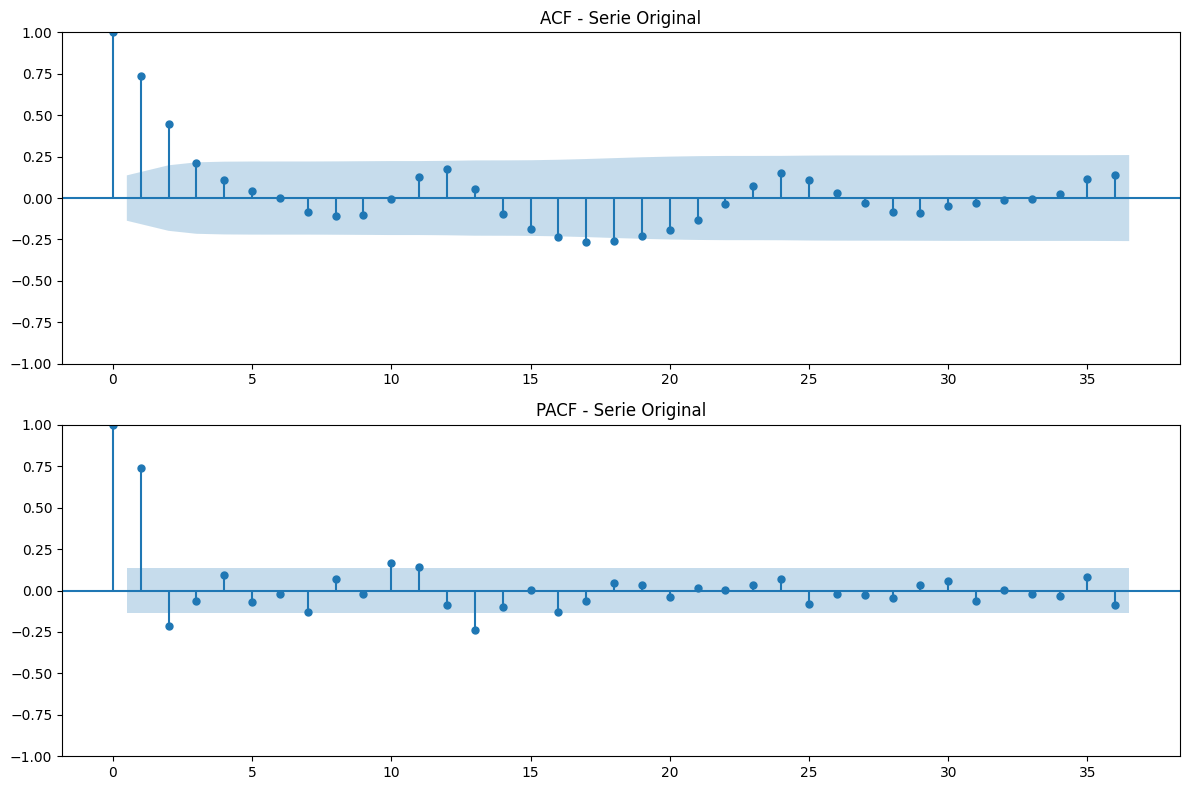

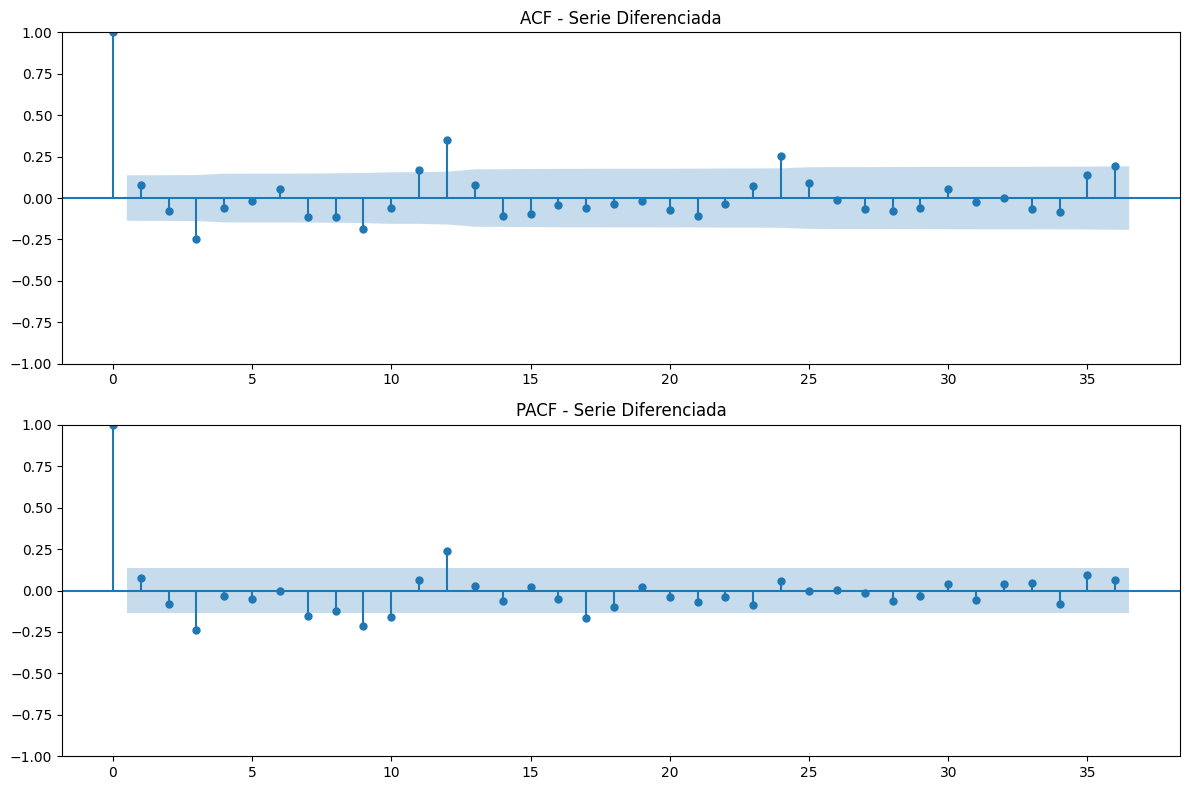

In [38]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Serie original
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train['y'], ax=ax[0], lags=36)
ax[0].set_title('ACF - Serie Original')
plot_pacf(train['y'], ax=ax[1], lags=36)
ax[1].set_title('PACF - Serie Original')
plt.tight_layout()
plt.show()

# Serie diferenciada
train_diff = train['y'].diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train_diff, ax=ax[0], lags=36)
ax[0].set_title('ACF - Serie Diferenciada')
plot_pacf(train_diff, ax=ax[1], lags=36)
ax[1].set_title('PACF - Serie Diferenciada')
plt.tight_layout()
plt.show()


In [37]:
from statsmodels.tsa.stattools import adfuller

# Prueba ADF en serie original
result = adfuller(train['y'])
print("ADF - Serie Original")
print(f"Estadístico: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("¿Es estacionaria?", "Sí" if result[1] < 0.05 else "No")
print()

# Prueba ADF en serie diferenciada
result_diff = adfuller(train_diff)
print("ADF - Serie Diferenciada (d=1)")
print(f"Estadístico: {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.4f}")
print("¿Es estacionaria?", "Sí" if result_diff[1] < 0.05 else "No")


ADF - Serie Original
Estadístico: -4.2687
p-value: 0.0005
¿Es estacionaria? Sí

ADF - Serie Diferenciada (d=1)
Estadístico: -4.8265
p-value: 0.0000
¿Es estacionaria? Sí


In [41]:
import statsmodels.api as sm

# Entrenar el modelo SARIMA(p,d,q)(P,D,Q,s)
# Puedes ajustar estos parámetros más adelante con grid search o auto_arima
model_sarima = sm.tsa.SARIMAX(
    train['y'],
    order=(1, 1, 1),              # p, d, q
    seasonal_order=(1, 1, 1, 12), # P, D, Q, s (s = 12 meses)
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# Predicción
pred_sarima = model_sarima.forecast(steps=12)

# Evaluación
mae_sarima = mean_absolute_error(test['y'], pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test['y'], pred_sarima))

print(f"SARIMA MAE: {mae_sarima:.2f}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")


SARIMA MAE: 700651.16
SARIMA RMSE: 1000895.42


In [17]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Inicializar y ajustar el modelo
model_prophet = Prophet()
model_prophet.fit(train)

# Crear dataframe para los próximos 12 meses
future = model_prophet.make_future_dataframe(periods=12, freq='MS')  # Month Start

# Generar predicción
forecast = model_prophet.predict(future)

# Extraer solo los valores correspondientes al test
forecast_test = forecast[['ds', 'yhat']].tail(12)

# Evaluar
mae_prophet = mean_absolute_error(test['y'].values, forecast_test['yhat'].values)
rmse_prophet = np.sqrt(mean_squared_error(test['y'].values, forecast_test['yhat'].values))

print(f"Prophet MAE: {mae_prophet:.2f}")
print(f"Prophet RMSE: {rmse_prophet:.2f}")


/home/jdperdomoq/epm-rnn101/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
18:16:47 - cmdstanpy - INFO - Chain [1] start processing
18:16:47 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 888432.72
Prophet RMSE: 960834.51


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Escalar la variable y
scaler = MinMaxScaler()
scaled_series = scaler.fit_transform(df_mensual[['y']].values)

# Función para crear secuencias de ventanas deslizantes
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Definir longitud de la ventana
SEQ_LENGTH = 12

X_all, y_all = create_sequences(scaled_series, SEQ_LENGTH)

# Dividir en train/test manualmente (últimos 12 como test)
X_train, X_test = X_all[:-12], X_all[-12:]
y_train, y_test = y_all[:-12], y_all[-12:]

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(32, activation='tanh', input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')  # más robusta ante outliers


early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

model.fit(X_train, y_train, epochs=300, batch_size=32, verbose=0, callbacks=[early_stop])

# Predecir
y_pred_scaled = model.predict(X_test)

# Invertir escalado
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test)

# Evaluar
mae_lstm = mean_absolute_error(y_test_inv, y_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred))

print(f"LSTM MAE: {mae_lstm:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")


/home/jdperdomoq/epm-rnn101/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
LSTM MAE: 777740.10
LSTM RMSE: 1137931.53


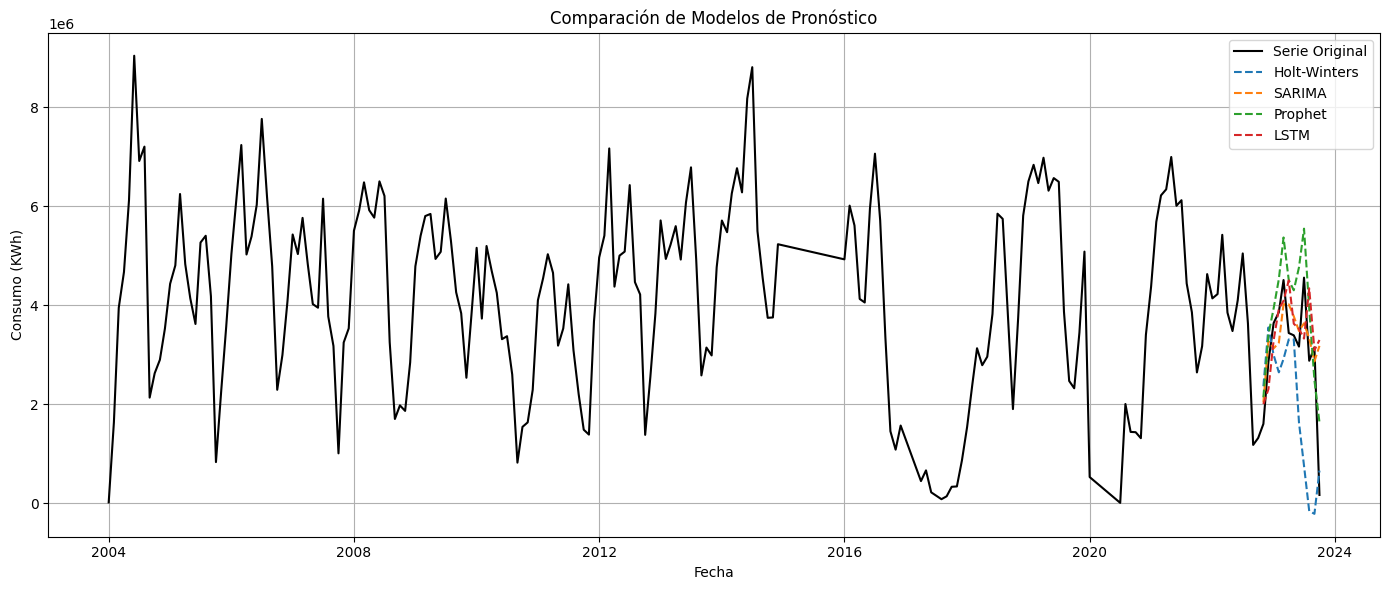

In [78]:
import matplotlib.pyplot as plt

# Construimos un dataframe para las predicciones de cada modelo
plot_df = test[['ds', 'y']].copy()
plot_df['Holt-Winters'] = pred_hw.values
plot_df['SARIMA'] = pred_sarima.values
plot_df['Prophet'] = forecast_test['yhat'].values
plot_df['LSTM'] = y_pred.flatten()  # y_pred ya está invertido el escalado

# Configuramos la gráfica
plt.figure(figsize=(14, 6))
plt.plot(df_mensual['ds'], df_mensual['y'], label='Serie Original', color='black')

# Agregamos las predicciones
plt.plot(plot_df['ds'], plot_df['Holt-Winters'], label='Holt-Winters', linestyle='--')
plt.plot(plot_df['ds'], plot_df['SARIMA'], label='SARIMA', linestyle='--')
plt.plot(plot_df['ds'], plot_df['Prophet'], label='Prophet', linestyle='--')
plt.plot(plot_df['ds'], plot_df['LSTM'], label='LSTM', linestyle='--')

# Estética del gráfico
plt.title('Comparación de Modelos de Pronóstico')
plt.xlabel('Fecha')
plt.ylabel('Consumo (KWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


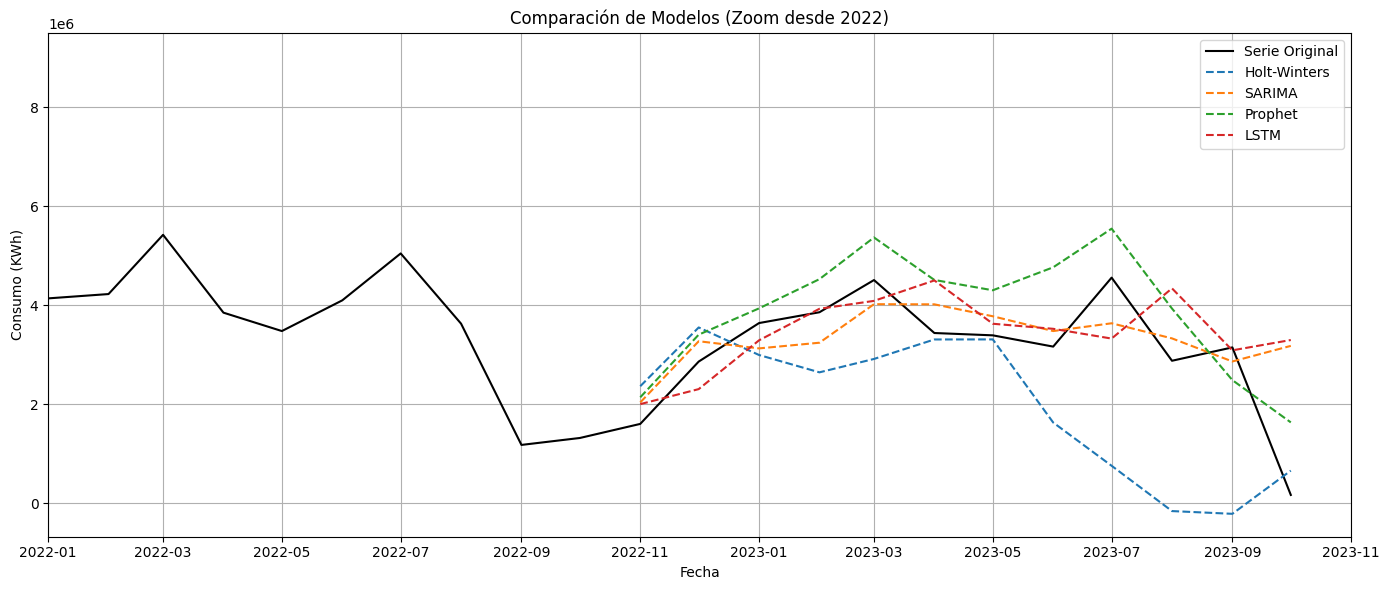

In [79]:
# Gráfica con zoom desde 2020
plt.figure(figsize=(14, 6))
plt.plot(df_mensual['ds'], df_mensual['y'], label='Serie Original', color='black')

# Agregamos las predicciones desde el test set
plt.plot(plot_df['ds'], plot_df['Holt-Winters'], label='Holt-Winters', linestyle='--')
plt.plot(plot_df['ds'], plot_df['SARIMA'], label='SARIMA', linestyle='--')
plt.plot(plot_df['ds'], plot_df['Prophet'], label='Prophet', linestyle='--')
plt.plot(plot_df['ds'], plot_df['LSTM'], label='LSTM', linestyle='--')

# Aplicamos zoom
plt.xlim(pd.Timestamp('2022-01-01'), df_mensual['ds'].max() + pd.DateOffset(months=1))

# Estética del gráfico
plt.title('Comparación de Modelos (Zoom desde 2022)')
plt.xlabel('Fecha')
plt.ylabel('Consumo (KWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
